In [1]:
### set up the notebook
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import scipy.signal
from scipy.interpolate import griddata
import dask as da

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
np.set_printoptions(linewidth=100) 

plt.rcParams.update({'font.size': 14})

da.config.set(**{'array.slicing.split_large_chunks': True})

In [2]:
### load the ACCESS and SWOT data and trim

# load ACCESS
access = xr.open_mfdataset('../data_to_publish/ACCESS_ZWD_bst_6_at_SWOT.nc')

# load SWOT
swot = xr.open_dataset('/data/hendreya/SWOT/SWOT_data/SWOT_L2_subsets_PGC0/SWOT_L2_LR_SSH_Expert_006_PGC0_02_bst.nc')

# load the GNSS
sn40 = xr.open_dataset('/data/hendreya/troposphere/data/GNSS/b011_sn40_soln_v1_JPLfixed_merged_smooth_hr_small.nc')
sn20 = xr.open_dataset('/data/hendreya/troposphere/data/GNSS/b008_sn20_soln_v1_JPLfixed_merged_smooth_hr_small.nc')
sn06 = xr.open_dataset('/data/hendreya/troposphere/data/GNSS/b012_sn06_soln_v1_JPLfixed_merged_smooth_hr_small.nc')
ss05 = xr.open_dataset('/data/hendreya/troposphere/data/GNSS/b014_ss05_soln_v1_JPLfixed_merged_smooth_hr_small.nc')
ss20 = xr.open_dataset('/data/hendreya/troposphere/data/GNSS/b015_ss20_soln_v1_JPLfixed_merged_smooth_hr_small.nc')
ss30 = xr.open_dataset('/data/hendreya/troposphere/data/GNSS/b013_ss30_soln_v1_JPLfixed_merged_smooth_hr_small.nc')
ss40 = xr.open_dataset('/data/hendreya/troposphere/data/GNSS/b010_ss40_soln_v1_JPLfixed_merged_smooth_hr_small.nc')
swxt = xr.open_dataset('/data/hendreya/troposphere/data/GNSS/b007_swxt_soln_v1_JPLfixed_merged_smooth_hr_small.nc')
sext = xr.open_dataset('/data/hendreya/troposphere/data/GNSS/b009_sext_soln_v1_JPLfixed_merged_smooth_hr_small.nc')

# buoy locations
buoy_loc = pd.read_csv('../data_to_publish/buoy_locations_FSP_latlon.csv')


In [3]:
### ensure datasets are consistent then combine

# drop cycle 3 from swot (no data), and replace 'cycle' with 'time' dim for consistency across datasets
swot = swot.drop_isel(cycle=3)

swot = swot.rename_vars({'time':'all_time'})
swot = swot.rename_dims({'cycle':'time'})
swot_times = swot.all_time.mean(axis=1)
swot = swot.assign_coords({'time': ('time', swot_times.values)})

# add access ZWD to swot dataset
swot['access_ZWD'] = (('time', 'num_lines', 'num_pixels'), access.ZWD.values)

# convert access to wet correction for consistency
swot['access_ZWD'] = swot.access_ZWD*-1

swot.load()


<xarray.Dataset>
Dimensions:                                (time: 95, num_lines: 244,
                                            num_pixels: 69, num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 -3...
    longitude                              (num_lines, num_pixels) float64 14...
    latitude_nadir                         (time, num_lines) float64 -37.38 ....
    longitude_nadir                        (time, num_lines) float64 145.1 .....
    cycle                                  (time) int16 476 478 479 ... 576 577
  * num_lines                              (num_lines) int16 7032 7033 ... 7275
  * num_pixels                             (num_pixels) int8 0 1 2 ... 66 67 68
  * time                                   (time) datetime64[ns] 2023-03-31T0...
Dimensions without coordinates: num_sides
Data variables: (12/99)
    all_time                               (time, num_lines) datetime64[ns] 2...
    time_tai                               (time, num_lines) datetime64[ns] 2...
    ssh_karin                              (time, num_lines, num_pixels) float64 ...
    ssh_karin_qual                         (time, num_lines, num_pixels) float64 ...
    ssh_karin_uncert                       (time, num_lines, num_pixels) float32 ...
    ssha_karin                             (time, num_lines, num_pixels) float64 ...
    ...                                     ...
    swh_ssb_cor_source_2                   (time, num_lines, num_pixels) float32 ...
    wind_speed_ssb_cor_source              (time, num_lines, num_pixels) float32 ...
    wind_speed_ssb_cor_source_2            (time, num_lines, num_pixels) float32 ...
    volumetric_correlation                 (time, num_lines, num_pixels) float32 ...
    volumetric_correlation_uncert          (time, num_lines, num_pixels) float32 ...
    access_ZWD                             (time, num_lines, num_pixels) float64 ...
Attributes: (12/63)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   JPL
    source:                                        Ka-band radar interferometer
    history:                                       2024-02-21T11:06:45Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       56.87923972950891
    ssha_variance:                                 0.47312923354534914
    references:                                    V1.2.1
    equator_longitude:                             138.19
    date_modified:                                 2024-04-12T07:16:59Z

In [4]:
### calculate residuals between radiometer and model

# select the line in the middle of the right swath at approx. rad location
swot_rad_line = swot.isel(num_pixels=50)

# calculate the residuals
rad_minus_access = swot_rad_line.rad_wet_tropo_cor - swot_rad_line.access_ZWD

# calculate the median Radiometer minus ACCESS wet trop correction and prepare for plotting
median_rad_minus_access = np.nanmedian(rad_minus_access.values, axis=0)

# Flatten the data from all time steps for plotting
num_lines_grid = np.tile(rad_minus_access.num_lines, (len(rad_minus_access.time),1))
num_lines_grid_flat = num_lines_grid.flatten()
rad_minus_access_flat = rad_minus_access.values.flatten() 

/working/hendreya/python_venvs/for_xarray/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1119: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


In [5]:
# reindex GNSS to swot times
sn40 = sn40.reindex(time=swot_times.values, method='nearest', tolerance='10min')
sn20 = sn20.reindex(time=swot_times.values, method='nearest', tolerance='10min')
sn06 = sn06.reindex(time=swot_times.values, method='nearest', tolerance='10min')
ss05 = ss05.reindex(time=swot_times.values, method='nearest', tolerance='10min')
ss20 = ss20.reindex(time=swot_times.values, method='nearest', tolerance='10min')
ss30 = ss30.reindex(time=swot_times.values, method='nearest', tolerance='10min')
swxt = swxt.reindex(time=swot_times.values, method='nearest', tolerance='10min')
sext = sext.reindex(time=swot_times.values, method='nearest', tolerance='10min')
ss40 = ss40.reindex(time=swot_times.values, method='nearest', tolerance='10min')

# save trop 
buoy_trop = np.zeros((9, len(swot_times)))
buoy_trop[0,:] = sn40.tropest_wet
buoy_trop[1,:] = sn20.tropest_wet
buoy_trop[2,:] = sn06.tropest_wet
buoy_trop[3,:] = ss05.tropest_wet
buoy_trop[4,:] = ss20.tropest_wet
buoy_trop[5,:] = ss30.tropest_wet
buoy_trop[6,:] = ss40.tropest_wet
buoy_trop[7,:] = swxt.tropest_wet
buoy_trop[8,:] = sext.tropest_wet

In [6]:
### extract radiometer at centre of swath closest to buoy locations 

# define the cross track pixel of our radiometer (~30 km from nadir)
rad_num_pix = 50

# create empty arrays for swot values (rad, dist to coast, line number)
swot_rad_center_buoys = np.zeros((9, len(swot_times)))
swot_dist_to_coast_center_buoys = np.zeros((9, len(swot_times)))
swot_line_center_buoys = np.zeros((9, len(swot_times)))

for i in range(len(swot_times)):
    swot_day = swot.isel(time=i)
    swot_line = swot_day.sel(num_pixels=rad_num_pix)
    
    # for each buoy select nearest swot lat, lon, rad
    for j in range(9):
        target_lat = buoy_loc.lat[j]
        target_lon = buoy_loc.lon[j]

        lat_diff = swot_line.latitude - target_lat
        lon_diff = swot_line.longitude - target_lon
        distance = np.sqrt(lat_diff**2 + lon_diff**2)

        # Find the indices of the minimum distance
        min_idx = np.argmin(distance.values)
        
        # save values
        swot_rad_center_buoys[j,i] = swot_line.rad_wet_tropo_cor[min_idx]
        swot_dist_to_coast_center_buoys[j,i] = swot_line.distance_to_coast[min_idx]
        swot_line_center_buoys[j,i] = swot_line.num_lines[min_idx]
        

In [8]:
### calculate the Radiometer minus GNSS wet trop correction and prepare for plotting

rad_minus_GNSS = np.zeros((9,95))
for i in range(9):
    rad_minus_GNSS[i,:] = swot_rad_center_buoys[i] + buoy_trop[i]
    
rad_minus_GNSS_list = [rad_minus_GNSS[i, ~np.isnan(rad_minus_GNSS[i, :])] for i in range(9)]

np.nanmean(swot_dist_to_coast_center_buoys, axis=1)/1000

array([51., 40., 33., 22., 15.,  6.,  1., 26.,  3.])

In [9]:
### add two empty data points for plotting purposes

rad_minus_GNSS_plot = [np.nan, np.nan] + rad_minus_GNSS_list
rad_minus_GNSS_plot_position = swot_line_center_buoys.mean(axis=1)
rad_minus_GNSS_plot_position = rad_minus_GNSS_plot_position.tolist()
rad_minus_GNSS_plot_position = [7160, 7180] + rad_minus_GNSS_plot_position

rad_minus_GNSS_plot_labels = ['84', '56', '51', '40', '33', '22', '15', '6', '1', '26', '3']

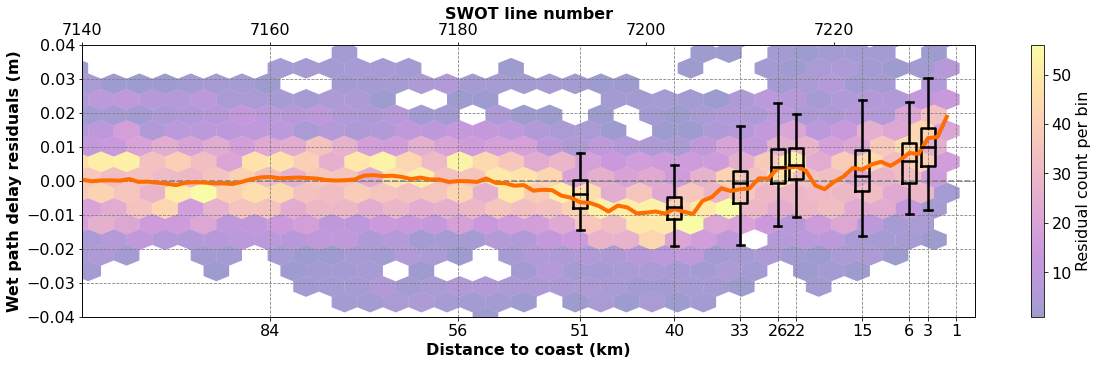

In [10]:
### Plot hexbin heatmap and median residuals

plt.rcParams.update({'font.size': 16})

fig, ax = plt.subplots(1, figsize=(20,5))
axes = [ax, ax.twiny()]

im = axes[1].hexbin(num_lines_grid_flat, rad_minus_access_flat, gridsize=(44,11), cmap='plasma', mincnt=1, 
                    C=None, alpha=0.4, edgecolors=None)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Residual count per bin')#, weight='bold')

boxprops = dict(linewidth=2.5)  # Set the line width for the box edges
whiskerprops = dict(linewidth=2.5)  # Set the line width for the whiskers
capprops = dict(linewidth=2.5)  # Set the line width for the caps
medianprops = dict(linewidth=2.5, c='k') #'#FE6D00')  # Set the line width for the median lines
axes[0].boxplot(rad_minus_GNSS_plot, positions=rad_minus_GNSS_plot_position, labels=rad_minus_GNSS_plot_labels, widths=1.5,
            boxprops=boxprops, 
            whiskerprops=whiskerprops, 
            capprops=capprops, 
            medianprops=medianprops, 
                showfliers=False)

axes[1].axhline(y=0, c='grey', linestyle='--')      
axes[0].plot(rad_minus_access.num_lines, median_rad_minus_access, color='#FE6D00', lw=4, label='Median Radiometer - ACCESS')
axes[1].plot([0,1],[0,1], c='k', label='Radiometer - GNSS\n')
               

ax.axvline()
for i in range(2):
    axes[i].set_xlim(7140, 7235)
    axes[i].set_ylim(-0.04, 0.04)
ax.grid(linestyle='--', color='grey')
ax.set_xlabel('Distance to coast (km)', weight='bold')
axes[1].set_xlabel('SWOT line number', weight='bold')
ax.set_ylabel('Wet path delay residuals (m)', weight='bold')

axes[0].patch.set_alpha(0)
axes[1].set_zorder(axes[1].get_zorder())
axes[0].set_zorder(axes[1].get_zorder()+1)

plt.show()